<h1 style="margin-bottom: 0.2em;">
One Voice, No Speaker?
</h1>

<h3 style="margin-top: 0; margin-bottom: 1.2em; font-weight: 400;">
Enunciative Effacement in Far-Right Parliamentary Speech, 2017–2022
</h3>


<blockquote style="margin-top: 2em;">
“Language, as the performance of all language, is neither reactionary nor progressive; it is quite simply fascist.”
— Roland Barthes, inaugural lecture at the Collège de France, January 7, 1977. [1]
</blockquote>

<blockquote style="margin-top: 1em">
“I embody common sense.”  — Marine Le Pen, 2010 and May 2019. [6]
</blockquote>


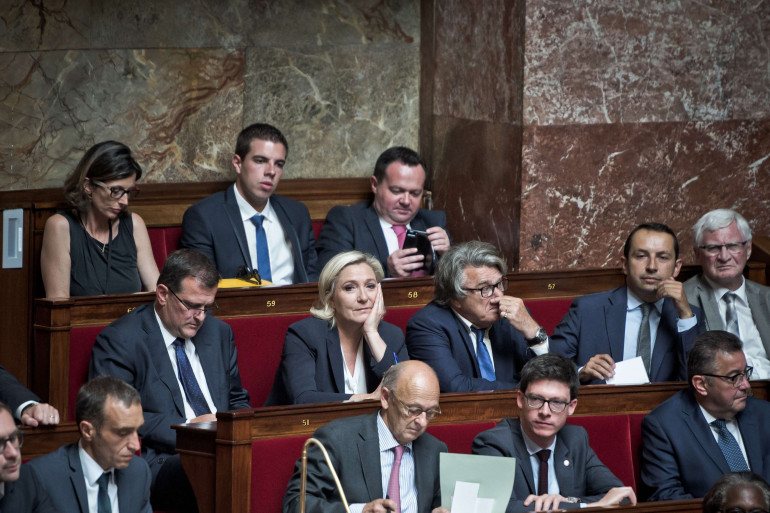

# 1. Question

Fascism is closely linked to the idea of unity: one people, one nation, one history, and one truth. For this reason, fascist discourse is not only defined by *what* it says, but also by *how* it says it. It often presents political ideas as natural, obvious, and beyond debate.

In fact, this project starts from Gill Seidel’s qualitative study of fascist discourse in the texts of the French *Nouvelle Droite* **[2]**. I extend this idea with a quantitative analysis of recent debates in the French National Assembly. I focus on the parliamentary far right, including the *Front National/Rassemblement national*, *Debout la France*, and other far-right deputies who were not part of a formal parliamentary group before 2022.

The project draws on Benveniste’s work on enunciation **[3]**. For Benveniste, the speaker is present in language through grammatical marks such as pronouns, verb forms, and other signs of subjectivity. When these marks disappear or become less visible, the discourse can appear less personal and more objective. This is what later scholars describe as *enunciative effacement*: the speaker seems to withdraw from the statement, so that the discourse appears to speak by itself.

This idea is connected to the far-right use of expressions such as “common sense” or, in French, *bon sens*. The linguist Julien Rault argues **[7]** that *bon sens* works as a political slogan because it presents a partisan position as something obvious and shared by everyone. In this sense, “common sense” can turn an ideological claim into an apparent truth. This is important for this project because it links far-right discourse to a broader rhetoric of objectivity and evidence.

The research question is:

### **Does the French far right distinguish itself from other parliamentary groups through stronger enunciative effacement?**

I answer this question by measuring three dimensions of enunciative effacement synthesized by the linguist Alain Rabatel in his study on the effects of enunciative effacement in reported speech **[4]** :  

1. First, I measure **explicit speaker presence**: do far-right deputies use fewer first-person markers, first-person subjects, and first-person verb forms?

   Example: *“Je rappelle du reste qu’il s’agissait d’une proposition du groupe Les Républicains.”*

      This sentence contains an explicit first-person marker: *"je"*. Thus it is not presented as detached from the speaker. Therefore, if a political group uses fewer forms like *"je"*, *"nous"*, first-person subjects, or first-person verbs, this goes in the direction of stronger enunciative effacement.

2. Second, I measure **syntactic impersonality**: do far-right deputies use more impersonal constructions, such as expletive subjects?

    Example: *“Il faut donc aider le patronat en défiscalisant les heures supplémentaires.”*

    This sentence uses an impersonal construction: *"il faut"*. The sentence does not say *"I think we should help"* or *"we want to help"*. Instead, the speaker is less visible because the sentence is organized around an impersonal structure. This is why I use expletive subjects, such as impersonal *"il"*, to measure syntactic impersonality.

3. Third, I measure **agent backgrounding**: do far-right deputies use more passive constructions, which make the agent of an action less visible?

   Example: *“Une mesure est adoptée.”*

      The action is presented, but the agent is not directly visible. Compared with an active sentence such as *"the Assembly adopts a measure"*, the passive form backgroundes the actor and gives more emphasis to the action itself. This is why I use passive auxiliaries and passive subjects to measure agent backgrounding.



# 2. Data

The project uses the annotated French component of ParlaMint, **ParlaMint-FR** [8]. The corpus contains parliamentary debates organized by year (from 2017 to 2022, between the two legislative elections taking place these 2 years). The annotated TEI files provide speaker metadata, parliamentary affiliations, lemmatized words, morphosyntactic features, and syntactic dependency relations.

The unit of analysis is one parliamentary intervention, corresponding to a `<u>` element in the XML files. For each intervention, I extract the date, speaker, parliamentary group, role of the speaker, topic code, section title, token count, lemmatized text, and grammatical features relevant to enunciative effacement.


## 2.1 Imports


In [43]:
import re
import glob
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

## 2.2 Paths


In [44]:
tei_dir = "../data/ParlaMint-FR.TEI.ana"

list_person = "../data/ParlaMint-FR.TEI.ana/ParlaMint-FR-listPerson.xml"
list_org = "../data/ParlaMint-FR.TEI.ana/ParlaMint-FR-listOrg.xml"

# xml:id is stored with its namespace in elementtree
xml_id = "{http://www.w3.org/XML/1998/namespace}id"


## 2.3 Utility functions


In [45]:
def local_name(tag):
    # parlamint tags use namespaces, but we only need the tag name
    return tag.split("}", 1)[-1] if "}" in tag else tag


def clean_text(elem):
    # section titles often contain hidden line breaks in xml
    return " ".join("".join(elem.itertext()).split())


## 2.4 Parliamentary groups


In [46]:
parliamentary_groups = {}

root_org = ET.parse(list_org).getroot()

for org in root_org.iter():
    if local_name(org.tag) != "org":
        continue
    
    org_id = org.attrib.get(xml_id)
    role = org.attrib.get("role", "")
    
    # party comparison uses parliamentary groups, not committees or institutions
    if org_id is None or role != "parliamentaryGroup":
        continue
    
    names = []
    
    for x in org.iter():
        if local_name(x.tag) == "orgName":
            names.append(clean_text(x))
    
    # one id is enough to match affiliations later
    parliamentary_groups[org_id] = names[0] if names else org_id

parliamentary_groups_df = pd.DataFrame(
    parliamentary_groups.items(),
    columns=["party_id", "party_name"]
)

parliamentary_groups_df.head(30)


,party_id,party_name
0,PO730934,Les Républicains
1,PO730940,Gauche démocrate et républicaine
2,PO730946,Nouvelle Gauche
3,PO730952,"Les Constructifs : républicains, UDI, indépend..."
4,PO730958,La France insoumise
5,PO730964,La République en Marche
6,PO730970,Mouvement Démocrate et apparentés
7,PO744425,"UDI, Agir et Indépendants"
8,PO758835,Socialistes et apparentés
9,PO759900,Libertés et Territoires


### 2.4.1 Harmonizing party labels 

Some parliamentary groups appear under several names because of institutional changes during the legislature. I harmonize only clear continuities, without merging broad political families.

The main regroupings are:

- **La République en Marche / Renaissance**: same presidential party continuity.
- **MoDem**: two labels refer to the same centrist group before and after naming changes.
- **UDI / Agir / Indépendants**: labels are kept together when they correspond to the same center-right parliamentary continuity.
- **Socialist group**: `Nouvelle Gauche` and `Socialistes et apparentés` refer to the socialist parliamentary group across time.

I keep groups such as `Les Républicains`, `La France insoumise`, `Gauche démocrate et républicaine`, `Libertés et Territoires`, and `Écologie Démocratie Solidarité` separate.

In [47]:
# harmonize clear party-label continuities
party_rename = {
    "Renaissance": "La République en Marche / Renaissance",
    "La République en Marche": "La République en Marche / Renaissance",
    
    "Mouvement Démocrate et apparentés": "Mouvement Démocrate",
    "Mouvement Démocrate (MoDem) et Démocrates apparentés": "Mouvement Démocrate",
    
    "UDI, Agir et Indépendants": "UDI / Agir / Indépendants",
    "UDI et Indépendants": "UDI / Agir / Indépendants",
    "Les Constructifs : républicains, UDI, indépendants": "UDI / Agir / Indépendants",
    "Agir ensemble": "UDI / Agir / Indépendants",
    
    "Nouvelle Gauche": "Socialistes et apparentés",
    "Socialistes et apparentés": "Socialistes et apparentés",
}

# update the dictionary used later to build speaker affiliations
for party_id, party_name in parliamentary_groups.items():
    parliamentary_groups[party_id] = party_rename.get(party_name, party_name)

# rebuild the inspection dataframe from the updated dictionary
parliamentary_groups_df = pd.DataFrame(
    parliamentary_groups.items(),
    columns=["party_id", "party_name"]
)

parliamentary_groups_df["party_name"].value_counts(dropna=False)

party_name
UDI / Agir / Indépendants                                               6
Les Républicains                                                        2
Socialistes et apparentés                                               2
Mouvement Démocrate                                                     2
La République en Marche / Renaissance                                   2
La France insoumise                                                     1
Gauche démocrate et républicaine                                        1
Libertés et Territoires                                                 1
Écologie Démocratie Solidarité                                          1
Démocrate (MoDem et Indépendants)                                       1
La France insoumise - Nouvelle Union Populaire écologique et sociale    1
Socialistes et apparentés (membre de l’intergroupe NUPES)               1
Gauche démocrate et républicaine - NUPES                                1
Horizons et apparentés     

## 2.5 Speakers and affiliations


### 2.5.1 Read speakers


In [48]:
speakers = {}

root_person = ET.parse(list_person).getroot()

for person in root_person.iter():
    if local_name(person.tag) != "person":
        continue
    
    speaker_id = person.attrib.get(xml_id)
    
    if speaker_id is None:
        continue
    
    names = []
    
    for x in person.iter():
        if local_name(x.tag) == "persName":
            names.append(clean_text(x))
    
    speaker_name = names[0] if names else speaker_id
    affiliations = []
    
    for aff in person.iter():
        if local_name(aff.tag) != "affiliation":
            continue
        
        ref = aff.attrib.get("ref", "")
        
        for r in ref.split():
            party_id = r.replace("#", "")
            
            # keep all valid group lines because a speaker can change group over time
            if party_id in parliamentary_groups:
                affiliations.append({
                    "party_id": party_id,
                    "party_name": parliamentary_groups[party_id],
                    "from": aff.attrib.get("from", ""),
                    "to": aff.attrib.get("to", "")
                })
    
    speakers[speaker_id] = {
        "speaker_name": speaker_name,
        "affiliations": affiliations
    }

print("number of speakers:", len(speakers))


number of speakers: 908


### 2.5.2 Inspect parliamentary affiliations


In [49]:
rows = []

for speaker_id, info in speakers.items():
    for aff in info["affiliations"]:
        rows.append({
            "speaker_id": speaker_id,
            "speaker_name": info["speaker_name"],
            "party_id": aff["party_id"],
            "party_name": aff["party_name"],
            "from": aff["from"],
            "to": aff["to"]
        })

affiliations_df = pd.DataFrame(rows)

# this table is useful to check speakers with several mandates or group changes
affiliations_df.head(30)


,speaker_id,speaker_name,party_id,party_name,from,to
0,PA-107289,Boris Vallaud,PO730946,Socialistes et apparentés,2017-06-27,2018-09-11
1,PA-107289,Boris Vallaud,PO758835,Socialistes et apparentés,2018-09-12,
2,PA-121259,Marie-Christine Dalloz,PO730934,Les Républicains,2017-06-27,
3,PA-121339,Olivia Grégoire,PO730964,La République en Marche / Renaissance,2017-06-27,2020-08-26
4,PA-1260,Marie-Christine Dalloz,PO730934,Les Républicains,2017-06-27,
5,PA1008,Alain David,PO730946,Socialistes et apparentés,2017-06-27,2018-09-11
6,PA1008,Alain David,PO758835,Socialistes et apparentés,2018-09-12,2022-06-21
7,PA1008,Alain David,PO800496,Socialistes et apparentés (membre de l’intergr...,2022-06-29,
8,PA1012,Charles de la Verpillière,PO730934,Les Républicains,2017-06-27,2022-06-21
9,PA1029,Bernard Deflesselles,PO730934,Les Républicains,2017-06-27,2022-06-21


### 2.5.3 Recode far-right deputies

Moreover, I need to recode FN/RN and broader far-right deputies directly in `party_name`. This step is necessary because, before 2022, far-right deputies often appear in ParlaMint as non-attached members rather than as a formal parliamentary group. If I dropped missing `party_name` values before this recoding, these deputies would disappear from the analysis.

These names were not chosen arbitrarily. They come from:
- either FN, the far-right party now called RN, originally founded by nazis;
- or Debout la France, another far-right party created by the nationalist Nicolas Dupont-Aignan;

All these deputies are recoded under the same analytical name: `FN/extreme_droite`.


In [50]:
# manual far-right label
extreme_right_names = [
    "Marine Le Pen",
    "Bruno Bilde",
    "Sébastien Chenu",
    "Louis Aliot",
    "Ludovic Pajot",
    "Myriane Houplain",
    "José Evrard",
    "Gilbert Collard",
    "Nicolas Meizonnet",
    "Catherine Pujol",
    "Jacques Bompard",
    "Marie-France Lorho",
    "Emmanuelle Ménard",
    "Nicolas Dupont-Aignan",
]

extreme_right_label = "FN/extreme_droite"
extreme_right_id = "FN_extreme_droite"

# recode manual list
for speaker_id, info in speakers.items():
    if info["speaker_name"] in extreme_right_names:
        info["affiliations"] = [{
            "party_id": extreme_right_id,
            "party_name": extreme_right_label,
            "from": "",
            "to": ""
        }]

# recode formal rn group if present
for speaker_id, info in speakers.items():
    for aff in info["affiliations"]:
        if "rassemblement national" in str(aff["party_name"]).lower():
            aff["party_id"] = extreme_right_id
            aff["party_name"] = extreme_right_label

# quick check
[
    info["speaker_name"]
    for info in speakers.values()
    if any(aff["party_name"] == extreme_right_label for aff in info["affiliations"])
]

['Nicolas Dupont-Aignan',
 'Jacques Bompard',
 'Gilbert Collard',
 'Hervé de Lépinau',
 'Nicolas Meizonnet',
 'Emmanuelle Ménard',
 'Sébastien Chenu',
 'Ludovic Pajot',
 'Myriane Houplain',
 'Marine Le Pen',
 'José Evrard',
 'Louis Aliot',
 'Catherine Pujol',
 'Bruno Bilde',
 'Marie-France Lorho',
 'Christian Girard',
 'Jérôme Buisson',
 'José Beaurain',
 'Jocelyn Dessigny',
 'Jordan Guitton',
 'Angélique Ranc',
 'Christophe Barthès',
 'Lionel Tivoli',
 'Emmanuel Taché de la Pagerie',
 'Franck Allisio',
 'Caroline Colombier',
 'Kévin Mauvieux',
 'Timothée Houssin',
 'Christine Loir',
 'Yoann Gillet',
 'Pierre Meurin',
 'Stéphanie Galzy',
 'Aurélien Lopez-Liguori',
 'Edwige Diaz',
 'Grégoire de Fournas',
 'Alexis Jolly',
 'Roger Chudeau',
 'Annick Cousin',
 'Mathilde Paris',
 'Thomas Ménagé',
 'Hélène Laporte',
 'Florence Goulet',
 'Christophe Bentz',
 'Michaël Taverne',
 'Pierrick Berteloot',
 'Matthieu Marchio',
 'Thibaut François',
 'Philippe Ballard',
 'Alexandre Sabatou',
 'Kévin P

## 2.6 Speech extraction


In [51]:
def choose_party_at_date(speaker_id, speech_date):
    # a speaker can have several affiliations, so the date must decide the group
    info = speakers.get(speaker_id)
    
    if info is None:
        return None, None
    
    speech_date = pd.to_datetime(speech_date)
    valid = []
    
    for aff in info["affiliations"]:
        start = pd.to_datetime(aff["from"]) if aff["from"] != "" else pd.NaT
        end = pd.to_datetime(aff["to"]) if aff["to"] != "" else pd.NaT
        
        # empty start or end dates mean an open interval
        starts_before = pd.isna(start) or start <= speech_date
        ends_after = pd.isna(end) or speech_date <= end
        
        if starts_before and ends_after:
            valid.append({
                "party_id": aff["party_id"],
                "party_name": aff["party_name"],
                "start": start
            })
    
    if len(valid) == 0:
        return None, None
    
    # if two affiliations overlap, the most recent one is the best match
    valid = sorted(
        valid,
        key=lambda x: x["start"] if not pd.isna(x["start"]) else pd.Timestamp.min,
        reverse=True
    )
    
    return valid[0]["party_id"], valid[0]["party_name"]


### 2.6.1 Read debate files


In [52]:
years = ["2017", "2018", "2019", "2020", "2021", "2022"]

debate_files = []

for year in years:
    # parlamint stores the debate files in one folder per year
    files_year = glob.glob(tei_dir + "/" + year + "/*.ana.xml")
    debate_files.extend(files_year)

print("number of debate files:", len(debate_files))
print(debate_files[:5])


number of debate files: 1564
['../data/ParlaMint-FR.TEI.ana/2017\\ParlaMint-FR_2017-06-27-O1124.ana.xml', '../data/ParlaMint-FR.TEI.ana/2017\\ParlaMint-FR_2017-06-28-O1125.ana.xml', '../data/ParlaMint-FR.TEI.ana/2017\\ParlaMint-FR_2017-07-03-C1001.ana.xml', '../data/ParlaMint-FR.TEI.ana/2017\\ParlaMint-FR_2017-07-03-O1001.ana.xml', '../data/ParlaMint-FR.TEI.ana/2017\\ParlaMint-FR_2017-07-04-E1001.ana.xml']


### 2.6.2 Extract speeches from XML files


*For this cell, I used ChatGPT to help resolve some errors. Sorry for the length of the function, but it did not work when I tried segmenting it.*

Here is the detailed explanation of the variables extracted from the XML files.

The measures are extracted from the annotated TEI XML files in ParlaMint-FR. The unit of analysis is the speech intervention, marked by the `<u>` element. Each `<u>` contains:

- the speaker identifier in the `who` attribute;
- the speech metadata in the `ana` attribute.

The speaker identifier is matched with `ParlaMint-FR-listPerson.xml`. This allows me to recover the speaker’s name and political affiliation at the date of the speech. This is important because the same speaker can have several affiliations over time.

The `ana` attribute is used to recover the speaker role and the topic code. For example, `#regular topic:lawcr` means that the intervention is a regular political speech and that its topic code is `lawcr`.

The words inside each speech are stored as `<w>` elements. These elements contain the lemma and the morphosyntactic tag `msd`. I use these annotations to measure explicit speaker presence:

- first-person pronouns and determiners: `Person=1` with `UPosTag=PRON` or `UPosTag=DET`;
- first-person finite verbs: `Person=1`, `VerbForm=Fin`, and `UPosTag=VERB` or `UPosTag=AUX`.

Syntactic relations are stored in `<link>` elements. I use these links to identify two other dimensions of enunciative effacement:

- expletive subjects, marked as `expl_subj`, measure syntactic impersonality;
- passive constructions, marked through relations such as `aux_pass` and `nsubj_pass`, measure agent backgrounding.

In [53]:
def extract_speeches_from_file(filename, min_tokens=50):
    # one output row corresponds to one <u> speech element
    rows = []
    
    base = filename.replace("\\", "/").split("/")[-1]
    m = re.search(r"ParlaMint-FR_(\d{4}-\d{2}-\d{2})-([OEC])", base)
    
    speech_date = m.group(1)
    session_letter = m.group(2)
    
    if session_letter == "O":
        session_type = "ordinary"
    elif session_letter == "E":
        session_type = "extraordinary"
    elif session_letter == "C":
        session_type = "congress"
    
    root = ET.parse(filename).getroot()
    
    for div in root.iter():
        if local_name(div.tag) != "div":
            continue
        
        div_head = ""
        note_text = ""
        
        for child in div:
            if local_name(child.tag) == "head":
                div_head = clean_text(child)
            
            if local_name(child.tag) == "note":
                note_text = clean_text(child)
        
        for u in div:
            if local_name(u.tag) != "u":
                continue
            
            speech_id = u.attrib.get(xml_id, "")
            
            who = u.attrib.get("who", "")
            speaker_id = who.split()[0].replace("#", "") if who else None
            
            speaker_name = speakers.get(speaker_id, {}).get("speaker_name", None)
            
            # group affiliation is matched using both speaker id and speech date
            party_id, party_name = choose_party_at_date(speaker_id, speech_date)
            
            ana = u.attrib.get("ana", "")
            speaker_role = ""
            topic_code = ""
            
            # ana contains the speech role and the parlamint topic label
            for part in ana.split():
                if part.startswith("#"):
                    speaker_role = part.replace("#", "")
                
                if part.startswith("topic:"):
                    topic_code = part.replace("topic:", "")
            
            lemmas = []
            token_info = {}
            
            n_finite_verbs = 0
            n_present_verbs = 0
            n_first_person_markers = 0
            n_first_person_finite_verbs = 0
            
            for x in u.iter():
                if local_name(x.tag) != "w":
                    continue
                
                token_id = x.attrib.get(xml_id, "")
                lemma = x.attrib.get("lemma")
                msd = x.attrib.get("msd", "")
                
                feats = {}
                
                # msd stores features such as person, tense, and part of speech
                for item in msd.split("|"):
                    if "=" in item:
                        key, value = item.split("=", 1)
                        feats[key] = value
                
                upos = feats.get("UPosTag", "")
                person = feats.get("Person", "")
                tense = feats.get("Tense", "")
                verb_form = feats.get("VerbForm", "")
                
                if lemma:
                    lemma = lemma.lower()
                    
                    # keep lemmatized alphabetic tokens only
                    if lemma.isalpha():
                        lemmas.append(lemma)
                
                # token_info is later used to interpret dependency links
                token_info[token_id] = {
                    "lemma": lemma,
                    "upos": upos,
                    "person": person,
                    "tense": tense,
                    "verb_form": verb_form
                }
                
                # first-person pronouns and determiners mark explicit speaker presence
                if person == "1" and upos in ["PRON", "DET"]:
                    n_first_person_markers += 1
                
                # finite verbs give a denominator for tense and person measures
                if upos in ["VERB", "AUX"] and verb_form == "Fin":
                    n_finite_verbs += 1
                    
                    if tense == "Pres":
                        n_present_verbs += 1
                    
                    if person == "1":
                        n_first_person_finite_verbs += 1
            
            n_subject_links = 0
            n_first_person_subjects = 0
            n_expletive_subjects = 0
            n_aux_pass = 0
            n_nsubj_pass = 0
            
            for x in u.iter():
                if local_name(x.tag) != "link":
                    continue
                
                rel = x.attrib.get("ana", "").replace("ud-syn:", "")
                target = x.attrib.get("target", "").split()
                
                if len(target) != 2:
                    continue
                
                dep = target[1].replace("#", "")
                
                # nsubj links make it possible to find first-person subjects
                if rel == "nsubj":
                    n_subject_links += 1
                    
                    dep_info = token_info.get(dep, {})
                    
                    if dep_info.get("person") == "1":
                        n_first_person_subjects += 1
                
                # expl_subj captures impersonal syntax such as il faut or il existe
                if rel == "expl_subj":
                    n_expletive_subjects += 1
                
                # passive links capture agent backgrounding
                if rel == "aux_pass":
                    n_aux_pass += 1
                
                if rel == "nsubj_pass":
                    n_nsubj_pass += 1
            
            if len(lemmas) >= min_tokens:
                rows.append({
                    "speech_id": speech_id,
                    "date": speech_date,
                    "session_type": session_type,
                    "speaker_id": speaker_id,
                    "speaker_name": speaker_name,
                    "party_id": party_id,
                    "party_name": party_name,
                    "speaker_role": speaker_role,
                    "topic_code": topic_code,
                    "div_head": div_head,
                    "note_text": note_text,
                    "n_tokens": len(lemmas),
                    "lemma_text": " ".join(lemmas),
                    "n_finite_verbs": n_finite_verbs,
                    "n_first_person_markers": n_first_person_markers,
                    "n_first_person_finite_verbs": n_first_person_finite_verbs,
                    "n_subject_links": n_subject_links,
                    "n_first_person_subjects": n_first_person_subjects,
                    "n_expletive_subjects": n_expletive_subjects,
                    "n_aux_pass": n_aux_pass,
                    "n_nsubj_pass": n_nsubj_pass
                })
    
    return pd.DataFrame(rows)


#### **WARNING : This cell has a long runtime sorry (it took 50 minutes for 1500 files on my computer)**

In [ ]:
max_files = 1564 # (~1 min runtime for 50 files) to do all the files you need to put at least 1564 

dfs = []

# each file returns a small speech-level dataframe
for f in debate_files[:max_files]:
    dfs.append(extract_speeches_from_file(f, min_tokens=50))

# concatenate all debate files into one table
speeches = pd.concat(dfs, ignore_index=True)

print("number of speeches:", len(speeches))

speeches.head()


number of speeches: 215350


,speech_id,date,session_type,speaker_id,speaker_name,party_id,party_name,speaker_role,topic_code,div_head,...,n_tokens,lemma_text,n_finite_verbs,n_first_person_markers,n_first_person_finite_verbs,n_subject_links,n_first_person_subjects,n_expletive_subjects,n_aux_pass,n_nsubj_pass
0,ParlaMint-FR_2017-06-27-O1124.u2,2017-06-27,ordinary,PA223837,Bernard Brochand,PO730934,Les Républicains,chair,other,Constitution du bureau d’âge,...,61,à le terme de le article de le règlement le si...,3,0,0,1,0,0,2,2
1,ParlaMint-FR_2017-06-27-O1124.u6,2017-06-27,ordinary,PA223837,Bernard Brochand,PO730934,Les Républicains,chair,civil,Allocution du doyen d’âge,...,628,monsieur le secrétaire de état charger de le r...,43,22,13,38,16,4,3,1
2,ParlaMint-FR_2017-06-27-O1124.u7,2017-06-27,ordinary,PA223837,Bernard Brochand,PO730934,Les Républicains,chair,mixed,Élection du président de l’Assemblée nationale,...,130,le ordre de le jour appeler conformément à le ...,10,3,3,7,2,0,4,4
3,ParlaMint-FR_2017-06-27-O1124.u9,2017-06-27,ordinary,PA223837,Bernard Brochand,PO730934,Les Républicains,chair,other,Élection du président de l’Assemblée nationale,...,61,le sort désigner le lettre pour faciliter le d...,6,3,3,5,3,0,2,2
4,ParlaMint-FR_2017-06-27-O1124.u12,2017-06-27,ordinary,PA223837,Bernard Brochand,PO730934,Les Républicains,chair,other,Élection du président de l’Assemblée nationale,...,92,le séance être reprendre son cher collègue voi...,4,2,2,4,2,0,1,1


## 2.7 Build the final dataset for analysis

In [55]:
df = speeches.copy()

# chair and guest turns are not ordinary political speeches
df = df[df["speaker_role"] == "regular"].copy()

# party_name now includes the manual far-right recoding
df = df.dropna(subset=["party_name", "lemma_text"])

# very short turns are noisy for grammatical rates
df = df[df["n_tokens"] >= 50].copy()

print("number of speeches:", len(df))
print("number of parties:", df["party_name"].nunique())

df["party_name"].value_counts()


number of speeches: 170349
number of parties: 10


party_name
La République en Marche / Renaissance    46392
Les Républicains                         36869
La France insoumise                      19740
Socialistes et apparentés                15534
UDI / Agir / Indépendants                12816
Gauche démocrate et républicaine         12642
Mouvement Démocrate                      12433
Libertés et Territoires                   8486
FN/extreme_droite                         4841
Écologie Démocratie Solidarité             596
Name: count, dtype: int64

# 3. Analysis

As previously said, the analysis focuses on enunciative effacement. I use three families of measures based on ParlaMint's morphosyntactic and syntactic annotations:

1. **explicit speaker presence**: first-person markers, first-person subjects, and first-person finite verbs;
2. **syntactic impersonality**: expletive subject constructions;
3. **agent backgrounding**: passive constructions.

The most useful comparisons are topic-controlled: each measure is residualized by `topic_code`, so groups are compared with other speeches on the same topic.


## 3.1 Build grammatical measures of enunciative effacement


All measures are normalized to make speeches comparable. First-person markers are expressed per 1,000 tokens. First-person subjects, expletive subjects, and passive constructions are expressed as shares or rates relative to the relevant grammatical denominator, such as subject links or finite verbs.


In [56]:
# family 1: direct grammatical presence of the speaker
df["first_person_marker_rate"] = (
    1000 * df["n_first_person_markers"] / df["n_tokens"]
)

# family 1: share of subjects that are first-person subjects
df["first_person_subject_share"] = (
    df["n_first_person_subjects"] / df["n_subject_links"]
)

# family 1: share of finite verbs conjugated in the first person
df["first_person_verb_share"] = (
    df["n_first_person_finite_verbs"] / df["n_finite_verbs"]
)

# family 2: impersonal subjects per 100 finite verbs
df["expletive_subject_rate"] = (
    100 * df["n_expletive_subjects"] / df["n_finite_verbs"]
)

# family 3: passive auxiliaries per 100 finite verbs
df["passive_aux_rate"] = (
    100 * df["n_aux_pass"] / df["n_finite_verbs"]
)

# family 3: passive subjects per 100 finite verbs
df["passive_subject_rate"] = (
    100 * df["n_nsubj_pass"] / df["n_finite_verbs"]
)


In [57]:
rate_cols = [
    "first_person_subject_share",
    "first_person_verb_share",
    "expletive_subject_rate",
    "passive_aux_rate",
    "passive_subject_rate",
]

# divisions by zero create infinite values when a speech has no denominator
for col in rate_cols:
    df.loc[np.isinf(df[col]), col] = np.nan


## 3.3 Descriptive comparison by group


In [58]:
# raw group means, before controlling for topic
effacement_by_party = (
    df.groupby("party_name")
      .agg(
          n_speeches=("speech_id", "count"),
          first_person_marker_rate=("first_person_marker_rate", "mean"),
          first_person_subject_share=("first_person_subject_share", "mean"),
          first_person_verb_share=("first_person_verb_share", "mean"),
          expletive_subject_rate=("expletive_subject_rate", "mean"),
          passive_aux_rate=("passive_aux_rate", "mean"),
          passive_subject_rate=("passive_subject_rate", "mean"),
      )
      .sort_values("expletive_subject_rate", ascending=False)
)

effacement_by_party


,n_speeches,first_person_marker_rate,first_person_subject_share,first_person_verb_share,expletive_subject_rate,passive_aux_rate,passive_subject_rate
party_name,,,,,,,
FN/extreme_droite,4841,18.668901,0.191207,0.153088,9.457615,9.198995,7.958551
Libertés et Territoires,8486,21.993499,0.241144,0.192966,9.065985,9.076994,8.860155
Écologie Démocratie Solidarité,596,21.643326,0.266851,0.219435,8.968147,8.554330,8.407458
Les Républicains,36869,21.463466,0.230557,0.188253,8.965268,8.970970,8.493631
UDI / Agir / Indépendants,12816,22.628657,0.255447,0.207960,8.724512,8.856975,8.399704
Mouvement Démocrate,12433,24.817209,0.275898,0.227771,8.583376,9.430469,9.033939
Socialistes et apparentés,15534,23.285002,0.254499,0.205756,8.485710,9.065451,8.743332
La France insoumise,19740,22.772925,0.233147,0.186801,8.361143,7.790858,7.646539
La République en Marche / Renaissance,46392,23.859818,0.274492,0.229552,8.043007,9.924638,9.398076


## 3.4 Topic-controlled comparison


Finally, the measures are residualized by `topic_code`. This means that, for each linguistic measure, I subtract the average value within the same topic. The resulting variables compare each political group to other speeches on similar subjects.

In [59]:
measures = [
    "first_person_marker_rate",
    "first_person_subject_share",
    "first_person_verb_share",
    "expletive_subject_rate",
    "passive_aux_rate",
    "passive_subject_rate",
]

df_topic = df.copy()

# topics with very few speeches make residual means unstable
df_topic = (
    df_topic.groupby("topic_code")
            .filter(lambda x: len(x) >= 20)
            .copy()
)

for col in measures:
    # residuals compare each speech with other speeches on the same topic
    df_topic[col + "_topic_resid"] = (
        df_topic[col]
        - df_topic.groupby("topic_code")[col].transform("mean")
    )


In [60]:
# this is the main descriptive table: group averages net of topic differences
effacement_by_party_topic = (
    df_topic.groupby("party_name")
            .agg(
                n_speeches=("speech_id", "count"),
                first_person_marker_resid=("first_person_marker_rate_topic_resid", "mean"),
                first_person_subject_resid=("first_person_subject_share_topic_resid", "mean"),
                first_person_verb_resid=("first_person_verb_share_topic_resid", "mean"),
                expletive_subject_resid=("expletive_subject_rate_topic_resid", "mean"),
                passive_aux_resid=("passive_aux_rate_topic_resid", "mean"),
                passive_subject_resid=("passive_subject_rate_topic_resid", "mean"),
            )
            .sort_values("expletive_subject_resid", ascending=False)
)

effacement_by_party_topic


,n_speeches,first_person_marker_resid,first_person_subject_resid,first_person_verb_resid,expletive_subject_resid,passive_aux_resid,passive_subject_resid
party_name,,,,,,,
FN/extreme_droite,4841,-3.963176,-0.057346,-0.049619,0.925632,0.013199,-0.705191
Libertés et Territoires,8486,-0.286984,-0.007458,-0.009838,0.492728,0.024815,0.192540
Les Républicains,36869,-1.317064,-0.020105,-0.016922,0.447149,-0.165587,-0.227842
Écologie Démocratie Solidarité,596,-0.944610,0.016200,0.014599,0.428376,-0.408003,-0.116338
UDI / Agir / Indépendants,12816,-0.027900,0.005087,0.003455,0.205860,-0.237493,-0.280334
Mouvement Démocrate,12433,1.758581,0.023599,0.020736,0.114800,0.311435,0.317893
Socialistes et apparentés,15534,0.445411,0.003635,0.000072,0.024256,-0.011245,0.039743
La France insoumise,19740,-0.036952,-0.017102,-0.018012,-0.094996,-1.294945,-1.003841
La République en Marche / Renaissance,46392,1.172072,0.024119,0.024630,-0.467876,0.805604,0.694765


#### Quick heatmap to look at the "raw" data

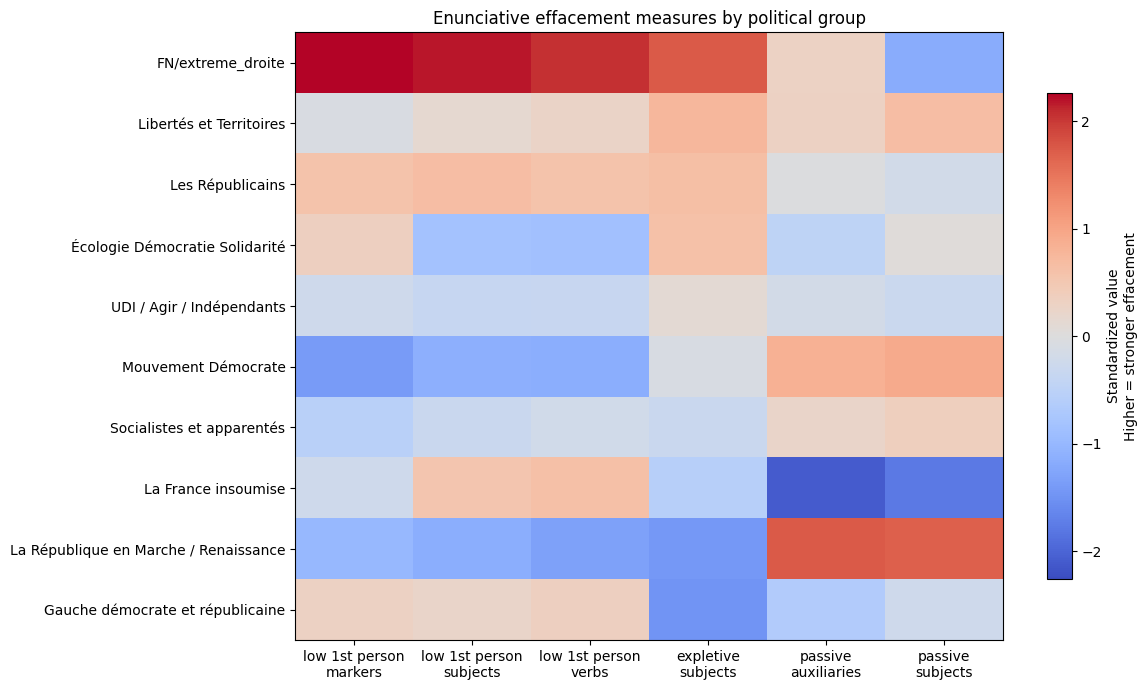

In [81]:
# variables from the descriptive table
heatmap_cols = [
    "first_person_marker_resid",
    "first_person_subject_resid",
    "first_person_verb_resid",
    "expletive_subject_resid",
    "passive_aux_resid",
    "passive_subject_resid",
]

# keep only the measures, not n_speeches
heatmap_data = effacement_by_party_topic[heatmap_cols].copy()

# remove tiny groups
heatmap_data = heatmap_data.loc[
    effacement_by_party_topic["n_speeches"] >= 50
]

# for first-person variables, lower values mean stronger effacement
speaker_presence_cols = [
    "first_person_marker_resid",
    "first_person_subject_resid",
    "first_person_verb_resid",
]

# reverse them so red always means stronger effacement
heatmap_data[speaker_presence_cols] = -heatmap_data[speaker_presence_cols]

# standardize each column so variables are comparable
heatmap_data_z = (
    heatmap_data
    - heatmap_data.mean()
) / heatmap_data.std()

# order groups by impersonal syntax
heatmap_data_z = heatmap_data_z.sort_values(
    "expletive_subject_resid",
    ascending=False
)

# nicer labels for the figure
nice_labels = {
    "first_person_marker_resid": "low 1st person\nmarkers",
    "first_person_subject_resid": "low 1st person\nsubjects",
    "first_person_verb_resid": "low 1st person\nverbs",
    "expletive_subject_resid": "expletive\nsubjects",
    "passive_aux_resid": "passive\nauxiliaries",
    "passive_subject_resid": "passive\nsubjects",
}

plot_data = heatmap_data_z.copy()
plot_data.columns = [nice_labels[col] for col in plot_data.columns]

# same color scale for positive and negative standardized values
vmax = np.nanmax(np.abs(plot_data.to_numpy()))

fig, ax = plt.subplots(figsize=(12, 7))

im = ax.imshow(
    plot_data,
    aspect="auto",
    cmap="coolwarm",
    vmin=-vmax,
    vmax=vmax
)

# add variable labels
ax.set_xticks(np.arange(len(plot_data.columns)))
ax.set_xticklabels(plot_data.columns)

# add party labels
ax.set_yticks(np.arange(len(plot_data.index)))
ax.set_yticklabels(plot_data.index)

# colorbar reads all columns in the same direction
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Standardized value\nHigher = stronger effacement")

ax.set_title("Enunciative effacement measures by political group")

plt.tight_layout()
plt.show()


## 3.5 Indexes

The three indexes correspond to the three dimensions of enunciative effacement introduced above: explicit speaker presence, syntactic impersonality, and agent backgrounding. Each index averages the standardized topic-residualized measures in its category, with signs adjusted so that higher values always mean stronger effacement.

In [62]:
# high values mean stronger effacement
def zscore(x):
    return (x - x.mean()) / x.std()

df_plot = df_topic.copy()

# less first-person presence means more speaker effacement
df_plot["speaker_effacement_index"] = -(
    zscore(df_plot["first_person_marker_rate_topic_resid"])
    + zscore(df_plot["first_person_subject_share_topic_resid"])
    + zscore(df_plot["first_person_verb_share_topic_resid"])
) / 3

# more expletive subjects means more impersonal syntax
df_plot["impersonal_syntax_index"] = (
    zscore(df_plot["expletive_subject_rate_topic_resid"])
)

# more passive syntax means more agent backgrounding
df_plot["agent_backgrounding_index"] = (
    zscore(df_plot["passive_aux_rate_topic_resid"])
    + zscore(df_plot["passive_subject_rate_topic_resid"])
) / 2

In [68]:
# one row per party with the three indexes
hemi_ring = (
    df_plot.groupby("party_name")
           .agg(
               n_speakers=("speaker_id", "nunique"),
               n_speeches=("speech_id", "count"),
               speaker_effacement_index=("speaker_effacement_index", "mean"),
               impersonal_syntax_index=("impersonal_syntax_index", "mean"),
               agent_backgrounding_index=("agent_backgrounding_index", "mean")
           )
           .reset_index()
)

# keep groups with enough data
hemi_ring = hemi_ring[hemi_ring["n_speeches"] >= 50].copy()

hemi_ring

,party_name,n_speakers,n_speeches,speaker_effacement_index,impersonal_syntax_index,agent_backgrounding_index
0,FN/extreme_droite,14,4841,0.286659,0.097666,-0.033859
1,Gauche démocrate et républicaine,17,12642,0.060125,-0.052326,-0.036348
2,La France insoumise,17,19740,0.070942,-0.010023,-0.111096
3,La République en Marche / Renaissance,341,46392,-0.120608,-0.049367,0.072551
4,Les Républicains,119,36869,0.097347,0.047180,-0.019072
5,Libertés et Territoires,25,8486,0.040095,0.051989,0.010605
6,Mouvement Démocrate,66,12433,-0.121895,0.012113,0.030459
7,Socialistes et apparentés,40,15534,-0.016773,0.002559,0.001405
8,UDI / Agir / Indépendants,56,12816,-0.017111,0.021721,-0.025082
9,Écologie Démocratie Solidarité,17,596,-0.043753,0.045199,-0.025224


## 3.6 Assembly visualization

I used ChatGPT to help me write code to generate this graph.

#### 3.6.1 Prepare data

In [87]:
# order parties from left to right
party_order = [
    "La France insoumise",
    "Gauche démocrate et républicaine",
    "Écologie Démocratie Solidarité",
    "Socialistes et apparentés",
    "Libertés et Territoires",
    "La République en Marche / Renaissance",
    "Mouvement Démocrate",
    "UDI / Agir / Indépendants",
    "Les Républicains",
    "FN/extreme_droite"
]

# keep parties present in the data
party_order = [p for p in party_order if p in hemi_ring["party_name"].tolist()]

# add parties not listed above
remaining = [p for p in hemi_ring["party_name"].tolist() if p not in party_order]
party_order = party_order + remaining

# apply the political order
hemi_ring["party_name"] = pd.Categorical(
    hemi_ring["party_name"],
    categories=party_order,
    ordered=True
)

hemi_ring = hemi_ring.sort_values("party_name").reset_index(drop=True)

# one ring for each index
metrics = [
    ("speaker_effacement_index", "Speaker\neffacement"),
    ("impersonal_syntax_index", "Impersonal\nsyntax"),
    ("agent_backgrounding_index", "Agent\nbackgrounding")
]

# short labels for readability
label_map = {
    "La France insoumise": "LFI",
    "Gauche démocrate et républicaine": "GDR",
    "Écologie Démocratie Solidarité": "EDS",
    "Socialistes et apparentés": "SOC",
    "Libertés et Territoires": "LT",
    "La République en Marche / Renaissance": "LREM/REN",
    "Mouvement Démocrate": "MoDem",
    "UDI / Agir / Indépendants": "UDI/Agir",
    "Les Républicains": "LR",
    "FN/extreme_droite": "FN/Far right"
}

# collect values for a common color scale
all_values = []

for col, _ in metrics:
    all_values.extend(hemi_ring[col].dropna().tolist())

# center the color scale around zero
vmax = np.nanmax(np.abs(all_values))

# party size is based on observed deputies
weights = hemi_ring["n_speakers"].to_numpy()
angle_widths = 180 * weights / weights.sum()

# create party arcs
angles = []
current_angle = 180

for width in angle_widths:
    start = current_angle
    end = current_angle - width
    angles.append((start, end))
    current_angle = end

#### 3.6.2 Draw plot

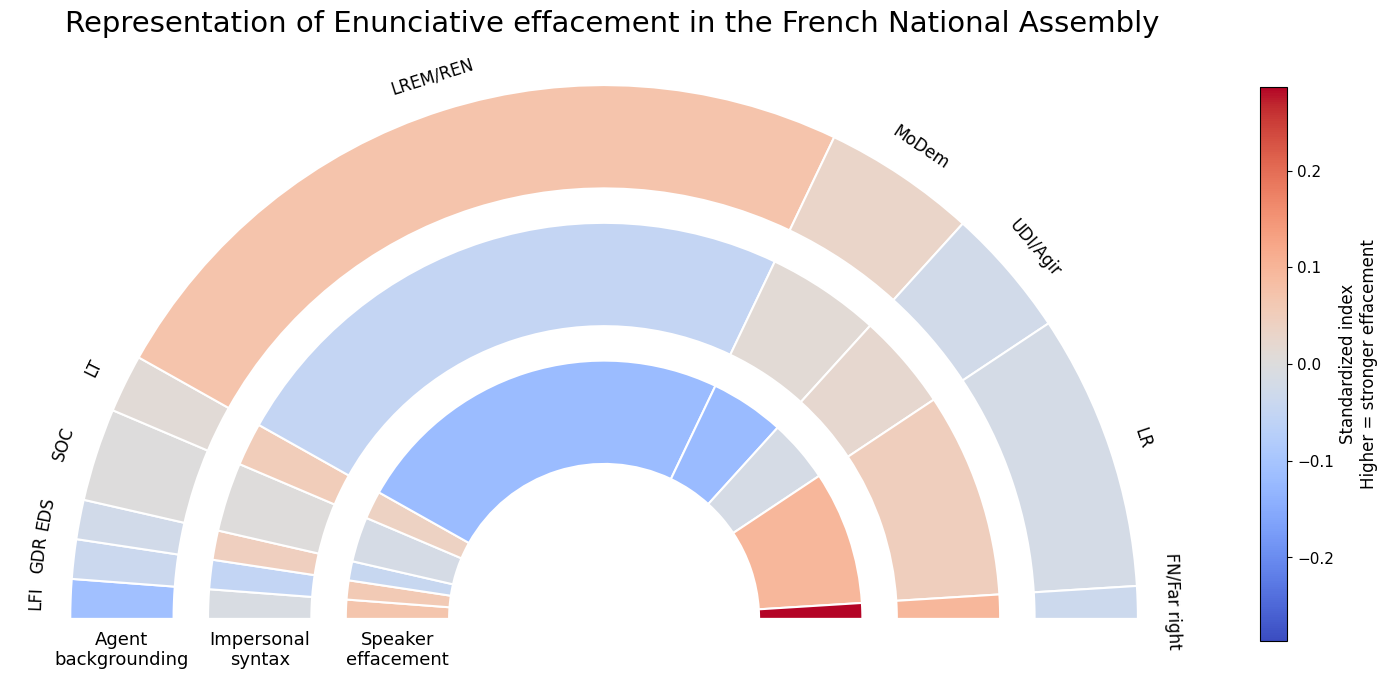

In [88]:
fig, ax = plt.subplots(figsize=(15, 8))
cmap = plt.cm.coolwarm

# ring size and spacing
inner_radius = 0.9
band_width = 0.6
gap = 0.2

# draw the rings
for ring_id, (metric_col, metric_label) in enumerate(metrics):
    
    r1 = inner_radius + ring_id * (band_width + gap)
    r2 = r1 + band_width
    
    for i, row in hemi_ring.iterrows():
        
        start, end = angles[i]
        value = row[metric_col]
        
        # map the value to the color scale
        color = cmap((value + vmax) / (2 * vmax))
        
        wedge = Wedge(
            center=(0, 0),
            r=r2,
            theta1=end,
            theta2=start,
            width=band_width,
            facecolor=color,
            edgecolor="white",
            linewidth=1.5
        )
        
        ax.add_patch(wedge)

# place party labels outside the rings
label_radius = inner_radius + len(metrics) * (band_width + gap) 

for i, row in hemi_ring.iterrows():
    
    start, end = angles[i]
    mid_deg = (start + end) / 2
    mid = np.deg2rad(mid_deg)
    
    x = label_radius * np.cos(mid)
    y = label_radius * np.sin(mid)
    
    label = label_map.get(row["party_name"], row["party_name"])
    
    # rotate labels with the curve
    rotation = mid_deg - 90
    
    # keep labels readable
    if rotation < -90:
        rotation += 180
    if rotation > 90:
        rotation -= 180
    
    ax.text(
        x,
        y,
        label,
        ha="center",
        va="center",
        fontsize=12,
        rotation=rotation,
        rotation_mode="anchor"
    )

# place index names below the matching rings
label_y = -0.18

for ring_id, (_, metric_label) in enumerate(metrics):
    
    r_mid = inner_radius + ring_id * (band_width + gap) + band_width / 2
    
    ax.text(
        -r_mid,
        label_y,
        metric_label,
        ha="center",
        va="center",
        fontsize=13,
        bbox=dict(
            boxstyle="round,pad=0.20",
            facecolor="white",
            edgecolor="none",
            alpha=0.88
        )
    )

# add colorbar
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin=-vmax, vmax=vmax)
)

sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, shrink=0.72, pad=0.03)
cbar.set_label(
    "Standardized index\nHigher = stronger effacement",
    fontsize=12
)
cbar.ax.tick_params(labelsize=11)

# final layout
ax.set_aspect("equal")
ax.axis("off")

ax.set_title(
    "Representation of Enunciative effacement in the French National Assembly",
    fontsize=21,
    pad=16
)

ax.set_xlim(-3.45, 3.55)
ax.set_ylim(-0.32, 3.28)

plt.tight_layout()
plt.show()

## 3.7 Linear regression test

In [89]:
import statsmodels.formula.api as smf

# use the dataset where indexes are already topic-controlled
reg_df = df_plot.copy()

# outcome variables: one test for each index
index_cols = [
    "speaker_effacement_index",
    "impersonal_syntax_index",
    "agent_backgrounding_index"
]

# main variable of interest
reg_df["far_right"] = (
    reg_df["party_name"] == "FN/extreme_droite"
).astype(int)

# simple controls
reg_df["year"] = pd.to_datetime(reg_df["date"]).dt.year
reg_df["log_tokens"] = np.log(reg_df["n_tokens"])

# section fixed effects
reg_df["section"] = (
    reg_df["note_text"]
    .fillna("missing")
    .replace("", "missing")
)

# keep complete rows for the regressions
reg_df = reg_df.dropna(
    subset=index_cols + [
        "far_right",
        "year",
        "log_tokens",
        "section",
        "speaker_id"
    ]
).copy()

results = []
models = {}

for y in index_cols:

    # indexes are topic-residualized, so topic is already controlled
    formula = y + " ~ far_right + log_tokens + C(year) + C(section)"

    model = smf.ols(
        formula,
        data=reg_df
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": reg_df["speaker_id"]}
    )

    models[y] = model

    # store the far-right coefficient and uncertainty
    results.append({
        "index": y,
        "coef": model.params["far_right"],
        "se": model.bse["far_right"],
        "p_value": model.pvalues["far_right"],
        "n_obs": int(model.nobs)
    })

reg_results = pd.DataFrame(results)

# confidence intervals
reg_results["ci_low"] = reg_results["coef"] - 1.96 * reg_results["se"]
reg_results["ci_high"] = reg_results["coef"] + 1.96 * reg_results["se"]

# clean labels for the plot
reg_results["index_label"] = reg_results["index"].replace({
    "speaker_effacement_index": "Speaker effacement",
    "impersonal_syntax_index": "Impersonal syntax",
    "agent_backgrounding_index": "Agent backgrounding"
})

reg_results



,index,coef,se,p_value,n_obs,ci_low,ci_high,index_label
0,speaker_effacement_index,0.297956,0.032351,3.260204e-20,170156,0.234548,0.361364,Speaker effacement
1,impersonal_syntax_index,0.091513,0.036921,1.318916e-02,170156,0.019148,0.163879,Impersonal syntax
2,agent_backgrounding_index,-0.040837,0.051682,4.294362e-01,170156,-0.142134,0.060460,Agent backgrounding


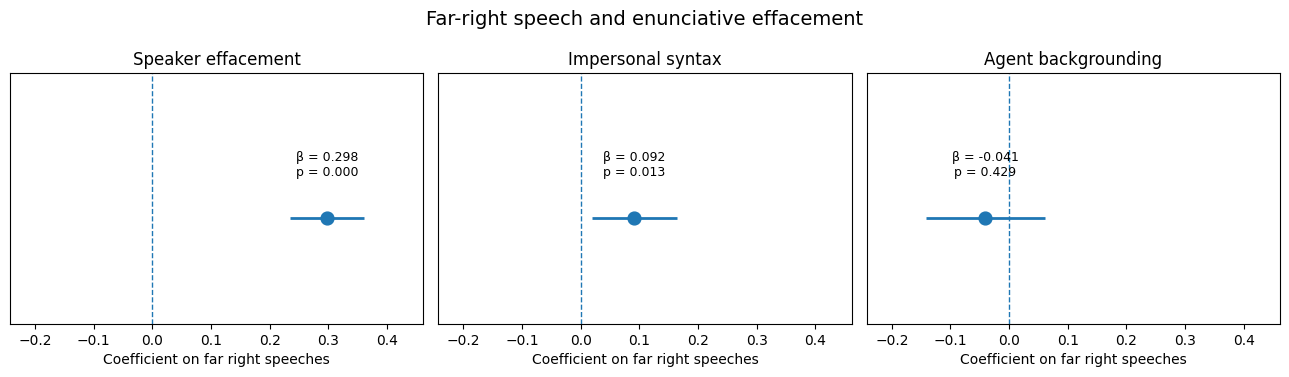

In [90]:
# plot one coefficient for each index
plot_df = reg_results.copy()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13, 3.8),
    sharex=True
)

# common x-axis across panels
xmin = plot_df["ci_low"].min()
xmax = plot_df["ci_high"].max()
pad = (xmax - xmin) * 0.20

for ax, (_, row) in zip(axes, plot_df.iterrows()):
    
    # confidence interval
    ax.hlines(
        y=0,
        xmin=row["ci_low"],
        xmax=row["ci_high"],
        linewidth=2
    )
    
    # point estimate
    ax.scatter(
        row["coef"],
        0,
        s=85,
        zorder=3
    )
    
    # zero means no difference with other parties
    ax.axvline(
        0,
        linestyle="--",
        linewidth=1
    )
    
    # panel title
    ax.set_title(
        row["index_label"],
        fontsize=12
    )
    
    # coefficient and p-value
    ax.text(
        row["coef"],
        0.13,
        f"β = {row['coef']:.3f}\np = {row['p_value']:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )
    
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(-0.35, 0.48)
    ax.set_yticks([])
    ax.set_xlabel("Coefficient on far right speeches")

fig.suptitle(
    "Far-right speech and enunciative effacement",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 4. Conclusion

The results support the main hypothesis, but only for some dimensions of enunciative effacement. The far-right category has the strongest negative values for first-person markers, first-person subjects, and first-person verbs. This means that, compared with other groups speaking on similar topics, far-right deputies make the speaker less grammatically visible.

The same pattern appears for syntactic impersonality. The far right has the highest value for expletive subjects, and the regression coefficient on `FN/extreme_droite` is positive and statistically significant for the impersonal syntax index. Far-right speeches therefore use more impersonal constructions, such as forms close to *il faut* or *il convient*, after controlling for year, speech length, and debate section.

The results are weaker for agent backgrounding. The coefficient is negative and not statistically significant for the passive-construction index. In this corpus, far-right enunciative effacement seems to work mainly through reduced speaker presence and impersonal syntax, rather than through passive constructions.

The main limitation of the study is the coding of far-right deputies before 2022. Before the creation of a clear parliamentary group for the Rassemblement national, far-right deputies often appeared as independent or non-attached deputies. The analysis therefore depends on a manual choice of which deputies should be coded as `FN/extreme_droite`. This choice is theoretically justified, but it remains the most important coding decision in the project.

Moreover, the project could be extended by measuring other forms of objectivizing language, such as references to *bon sens*, *évidence*, or *réalité*.

## References

**[1]** Barthes, Roland. 1977. Inaugural lecture at the Collège de France.

**[2]** Seidel, Gill. 1981. “Le fascisme dans les textes de la Nouvelle Droite.” *Mots. Les langages du politique* 3.

**[3]** Benveniste, Émile. 1966. *Problèmes de linguistique générale, 1*. Paris: Gallimard.

**[4]** Rabatel, Alain. 2004. “L’effacement énonciatif dans les discours rapportés et ses effets pragmatiques.” *Langages* 156: 3–17.

**[5]** Trump, Donald. 2024. Victory speech, November 6, 2024.

**[6]** Le Pen, Marine. 2010 and 2019 statements on *bon sens*, cited in Julien Rault.

**[7]** Rault, Julien. “Le bon sens en politique: analyse d’un mot d’ordre contemporain.” Université de Poitiers / The Conversation France.

**[8]** ParlaMint-FR. Annotated French parliamentary corpus, ParlaMint project.
